In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MLP

# MLP Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(load=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")                      # TODO: implement gpu

Using device: cpu


In [4]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [128]*4

BATCH_SIZE = 256
LEARNING_RATE = 1e-3
n_epochs = 5000

In [5]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
mlp1 = MLP(in_size, h_size, out_size, norm="layer").to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=30, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

summary(mlp1, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [256, 201]                --
├─Linear: 1-1                            [256, 128]                91,520
├─LayerNorm: 1-2                         [256, 128]                256
├─ReLU: 1-3                              [256, 128]                --
├─ModuleList: 1-4                        --                        --
│    └─MLPhlayer: 2-1                    [256, 128]                --
│    │    └─Linear: 3-1                  [256, 128]                16,512
│    │    └─LayerNorm: 3-2               [256, 128]                256
│    │    └─ReLU: 3-3                    [256, 128]                --
│    └─MLPhlayer: 2-2                    [256, 128]                --
│    │    └─Linear: 3-4                  [256, 128]                16,512
│    │    └─LayerNorm: 3-5               [256, 128]                256
│    │    └─ReLU: 3-6                    [256, 128]                --


In [ ]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

In [ ]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [ ]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [ ]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

In [ ]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=3)

# MLP Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [7]:
DAT1 = DATA(load=True, format=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [8]:
DAT1.train_in1.shape, DAT1.dx_out1.shape

((357, 2), (3588, 357, 1))

In [9]:
in_size = DAT1.train_in1.shape[-1]
out_size = DAT1.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 10

In [10]:
trainDS1x = Dataset_(DAT1.train_in1, DAT1.dx_out1[0])
trainDS1y = Dataset_(DAT1.train_in1, DAT1.dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

summary(mlp2, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 1]                    --
├─Linear: 1-1                            [1, 10]                   30
├─ReLU: 1-2                              [1, 10]                   --
├─ModuleList: 1-3                        --                        --
│    └─MLPhlayer: 2-1                    [1, 100]                  --
│    │    └─Linear: 3-1                  [1, 100]                  1,100
│    │    └─ReLU: 3-2                    [1, 100]                  --
│    └─MLPhlayer: 2-2                    [1, 100]                  --
│    │    └─Linear: 3-3                  [1, 100]                  10,100
│    │    └─ReLU: 3-4                    [1, 100]                  --
│    └─MLPhlayer: 2-3                    [1, 10]                   --
│    │    └─Linear: 3-5                  [1, 10]                   1,010
│    │    └─ReLU: 3-6                    [1, 10]                   --
├─Lin

In [ ]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

In [ ]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [ ]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - DAT1.dx_out1[0,:,0]), min(test_outputs[:,0] - DAT1.dx_out1[0,:,0])

In [ ]:
plot_Distribution(DAT1.train_in1, test_outputs[:,0], dx_out1=DAT1.dx_out1[0,:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [3]:
DAT2 = DATA(load=True, format=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
DAT2.train_in2.shape, DAT2.dx_out2.shape

((2, 714), (3588, 2, 357))

In [5]:
in_size = DAT2.train_in2.shape[-1]
out_size = DAT2.dx_out2.shape[-1]
h_size = []

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 1000000

h_size[:-1], h_size[1:]

([], [])

In [6]:
trainDS1x = Dataset_(DAT2.train_in2, DAT2.dx_out2[0])
trainDS1y = Dataset_(DAT2.train_in2, DAT2.dy_out2[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
mlp3 = MLP(in_size, h_size, out_size, bias=False).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

summary(mlp3, input_size=(BATCH_SIZE, in_size))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 357]                  --
├─Linear: 1-1                            [1, 357]                  254,898
Total params: 254,898
Trainable params: 254,898
Non-trainable params: 0
Total mult-adds (M): 0.25
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 1.02
Estimated Total Size (MB): 1.03

In [8]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 13368.4677734375
Epoch: 10 - Loss: 7930.77783203125
Epoch: 20 - Loss: 4137.66015625
Epoch: 30 - Loss: 1991.1302490234375
Epoch: 40 - Loss: 865.7947998046875
Epoch: 50 - Loss: 308.2463684082031
Epoch: 60 - Loss: 77.47914123535156
Epoch: 70 - Loss: 14.765984535217285
Epoch: 80 - Loss: 1.953684687614441
Epoch: 90 - Loss: 1.4542560577392578
Epoch: 100 - Loss: 0.20187625288963318
Epoch: 110 - Loss: 0.1078278124332428
Epoch: 120 - Loss: 0.022232431918382645
Epoch: 130 - Loss: 0.01094728335738182
Epoch: 140 - Loss: 0.005404500290751457
Epoch: 150 - Loss: 0.0030650414992123842
Epoch: 160 - Loss: 0.004213476553559303
Epoch 00166: reducing learning rate of group 0 to 2.8000e-05.
Epoch: 170 - Loss: 0.002235870808362961
Epoch: 180 - Loss: 0.002347825560718775
Epoch: 190 - Loss: 0.0014734750147908926
Epoch: 200 - Loss: 0.001380384317599237
Epoch: 210 - Loss: 0.001238495809957385
Epoch 00213: reducing learning rate of group 0 to 1.9600e-05.
Epoch: 220 - Loss: 0.0006150195840746164
E

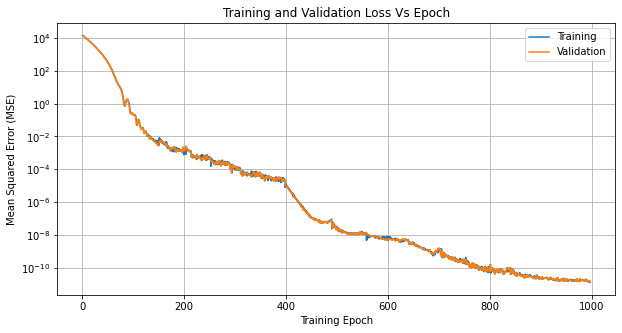

In [9]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [10]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - DAT2.dx_out2[0,0])), min(abs(test_outputs[0] - DAT2.dx_out2[0,0]))

(1.6845716857005755e-05, 8.300773401970218e-10)

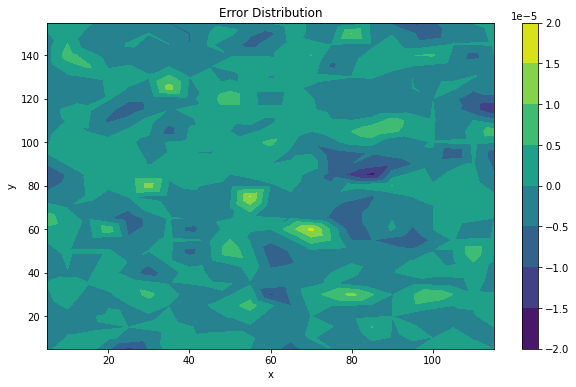

In [11]:
plot_Distribution(DAT2.train_in1, test_outputs[0], dx_out1=DAT2.dx_out2[0,0], typ="contour")

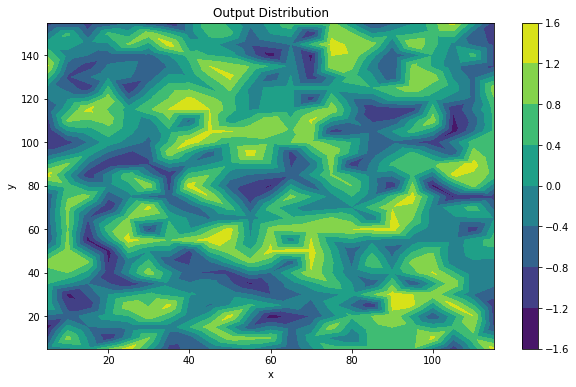

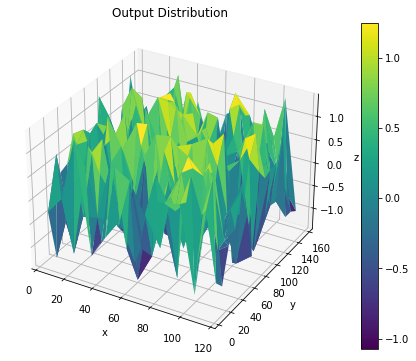

In [12]:
plot_Distribution(DAT2.train_in1, test_outputs[0], typ="both")

In [18]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\nTotal params: {param.numel()}\n")

fcOUT.weight: torch.Size([357, 714])
tensor([[ 0.0702, -0.1281,  0.0876,  ..., -0.0006,  0.0906, -0.0417],
        [ 0.0878,  0.0399, -0.0300,  ...,  0.0278,  0.0183, -0.0110],
        [-0.1210, -0.0498, -0.0440,  ...,  0.0101, -0.0279, -0.0170],
        ...,
        [ 0.0839, -0.0283,  0.0581,  ...,  0.0224, -0.0525,  0.0392],
        [-0.0590, -0.0557,  0.0151,  ..., -0.0561, -0.0044, -0.0112],
        [-0.0543, -0.0383,  0.0192,  ..., -0.0157,  0.0433, -0.0244]])
Total params: 254898

